In [2]:
!pip install datasets pandas scikit-learn matplotlib

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler

In [3]:
from datasets import load_dataset

# This downloads the dataset structure (features are loaded on demand)
dataset = load_dataset("Amgharr/FEMTO-ST_DATASET")

# Load only the training features (455 MB - manageable)
train_df = dataset['train'].to_pandas()

# Quick check
print(f"Training samples: {len(train_df)}")
print(f"Features: {train_df.columns.tolist()}")
print(train_df.head())

README.md:   0%|          | 0.00/338 [00:00<?, ?B/s]

features_train.parquet: reconstructing file:   0%|          |  0.00B /  466MB            

features_train.parquet: downloading bytes:           |  0.00B            

features_val.parquet: reconstructing file:   0%|          |  0.00B /  957MB            

features_val.parquet: downloading bytes:           |  0.00B            

...

features_test.parquet: downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/19287040 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/40773120 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/35735040 [00:00<?, ? examples/s]

Training samples: 19287040
Features: ['ax', 'ay', 'mag', 'ax_diff', 'ay_diff', 'mag_diff', 'source_file']
      ax     ay       mag  ax_diff  ay_diff  mag_diff    source_file
0 -0.176 -0.199  0.265663    0.000    0.000  0.000000  acc_01192.csv
1 -0.038 -0.030  0.048415    0.138    0.169 -0.217248  acc_01192.csv
2 -0.029 -0.261  0.262606    0.009   -0.231  0.214191  acc_01192.csv
3 -0.169  0.271  0.319378   -0.140    0.532  0.056771  acc_01192.csv
4 -0.241  0.612  0.657742   -0.072    0.341  0.338365  acc_01192.csv


In [5]:
# How many unique files (snapshots)?
print(f"Unique source files: {train_df['source_file'].nunique()}")

# How many rows per file?
rows_per_file = train_df.groupby('source_file').size()
print(f"Rows per file: {rows_per_file.iloc[0]}")

# List first few source files
print(train_df['source_file'].unique()[:5])

Unique source files: 2803
Rows per file: 15360
['acc_01192.csv' 'acc_00411.csv' 'acc_02422.csv' 'acc_01115.csv'
 'acc_01712.csv']


In [8]:
import numpy as np

def extract_features(snapshot):
    x = snapshot['ax'].values
    y = snapshot['ay'].values

    features = {
        'rms_x': np.sqrt(np.mean(x**2)),
        'rms_y': np.sqrt(np.mean(y**2)),
        'kurtosis_x': np.mean((x - np.mean(x))**4) / (np.std(x)**4),
        'kurtosis_y': np.mean((y - np.mean(y))**4) / (np.std(y)**4),
        'peak_to_peak_x': np.max(x) - np.min(x),
        'peak_to_peak_y': np.max(y) - np.min(y),
    }
    return features

# Apply to each snapshot
feature_rows = []
for file, group in train_df.groupby('source_file'):
    feats = extract_features(group)
    feats['source_file'] = file
    feature_rows.append(feats)

features_df = pd.DataFrame(feature_rows)
print(features_df.head())

      rms_x     rms_y  kurtosis_x  kurtosis_y  peak_to_peak_x  peak_to_peak_y  \
0  0.453035  0.321491    3.789482    4.087333           4.539           3.364   
1  0.435440  0.325260    3.556488    4.163825           3.897           3.331   
2  0.444564  0.332183    3.623464    3.973804           3.961           3.648   
3  0.460061  0.344576    3.538883    4.078708           4.036           3.683   
4  0.456636  0.341929    3.445904    3.846735           3.791           3.614   

     source_file  
0  acc_00001.csv  
1  acc_00002.csv  
2  acc_00003.csv  
3  acc_00004.csv  
4  acc_00005.csv  


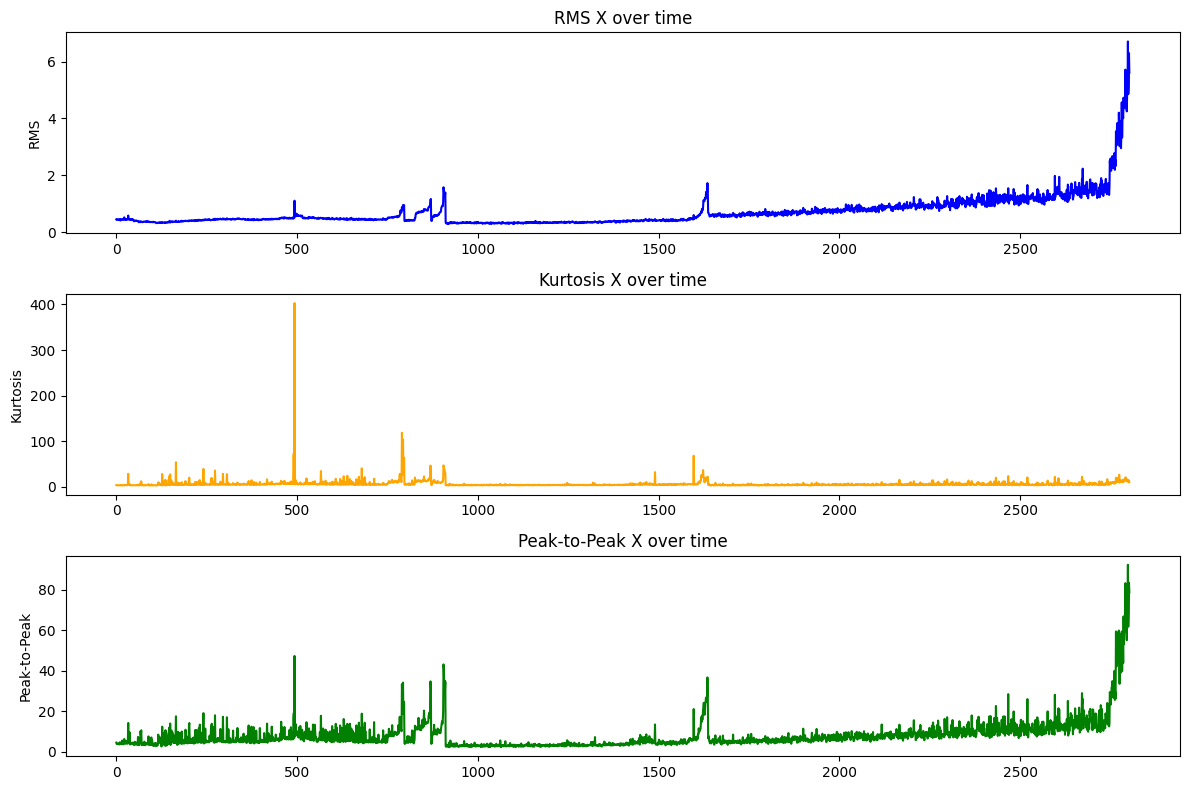

In [9]:
import matplotlib.pyplot as plt

# Add a numeric time index
features_df['snapshot_index'] = range(len(features_df))

# Plot RMS over time
fig, axes = plt.subplots(3, 1, figsize=(12, 8))

axes[0].plot(features_df['snapshot_index'], features_df['rms_x'], color='blue')
axes[0].set_title('RMS X over time')
axes[0].set_ylabel('RMS')

axes[1].plot(features_df['snapshot_index'], features_df['kurtosis_x'], color='orange')
axes[1].set_title('Kurtosis X over time')
axes[1].set_ylabel('Kurtosis')

axes[2].plot(features_df['snapshot_index'], features_df['peak_to_peak_x'], color='green')
axes[2].set_title('Peak-to-Peak X over time')
axes[2].set_ylabel('Peak-to-Peak')

plt.tight_layout()
plt.savefig('feature_evolution.png', dpi=150)
plt.show()

In [11]:
def extract_fft_features(snapshot):
    x = snapshot['ax'].values
    y = snapshot['ay'].values

    # Apply FFT to X-axis
    fft_x = np.abs(np.fft.rfft(x))
    freqs_x = np.fft.rfftfreq(len(x), d=1/25600)

    # Apply FFT to Y-axis
    fft_y = np.abs(np.fft.rfft(y))
    freqs_y = np.fft.rfftfreq(len(y), d=1/25600)

    # Band energies for X
    low_x = np.sum(fft_x[(freqs_x >= 0) & (freqs_x < 5000)])
    mid_x = np.sum(fft_x[(freqs_x >= 5000) & (freqs_x < 10000)])
    high_x = np.sum(fft_x[(freqs_x >= 10000) & (freqs_x < 20000)])

    # Band energies for Y
    low_y = np.sum(fft_y[(freqs_y >= 0) & (freqs_y < 5000)])
    mid_y = np.sum(fft_y[(freqs_y >= 5000) & (freqs_y < 10000)])
    high_y = np.sum(fft_y[(freqs_y >= 10000) & (freqs_y < 20000)])

    return {
        'band_low_x': low_x, 'band_mid_x': mid_x, 'band_high_x': high_x,
        'band_low_y': low_y, 'band_mid_y': mid_y, 'band_high_y': high_y
    }

In [12]:
fft_rows = []
for file, group in train_df.groupby('source_file'):
    feats = extract_fft_features(group)
    feats['source_file'] = file
    fft_rows.append(feats)

fft_df = pd.DataFrame(fft_rows)
features_df = features_df.merge(fft_df, on='source_file')

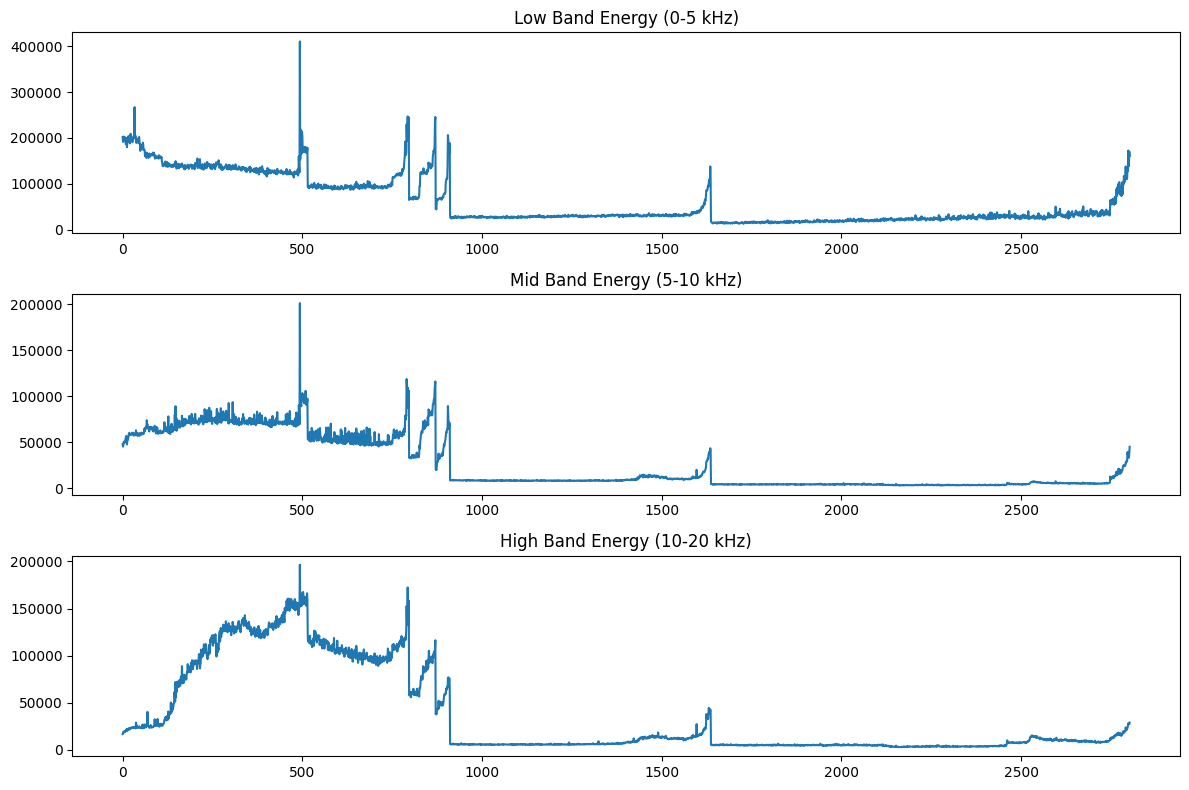

In [13]:
fig, axes = plt.subplots(3, 1, figsize=(12, 8))

axes[0].plot(features_df['snapshot_index'], features_df['band_low_x'])
axes[0].set_title('Low Band Energy (0-5 kHz)')

axes[1].plot(features_df['snapshot_index'], features_df['band_mid_x'])
axes[1].set_title('Mid Band Energy (5-10 kHz)')

axes[2].plot(features_df['snapshot_index'], features_df['band_high_x'])
axes[2].set_title('High Band Energy (10-20 kHz)')

plt.tight_layout()
plt.savefig('fft_features.png', dpi=150)
plt.show()

In [14]:
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler

# Select all features
feature_cols = [
    'rms_x', 'rms_y', 'kurtosis_x', 'kurtosis_y',
    'peak_to_peak_x', 'peak_to_peak_y',
    'band_low_x', 'band_mid_x', 'band_high_x',
    'band_low_y', 'band_mid_y', 'band_high_y'
]

X = features_df[feature_cols].values
X_scaled = StandardScaler().fit_transform(X)

# Train Isolation Forest
model = IsolationForest(
    contamination=0.1,
    random_state=42,
    n_estimators=100
)

features_df['anomaly'] = model.fit_predict(X_scaled)
features_df['anomaly_score'] = model.decision_function(X_scaled)

# Count anomalies
print(f"Anomalies detected: {(features_df['anomaly'] == -1).sum()}")
print(f"Normal points: {(features_df['anomaly'] == 1).sum()}")

Anomalies detected: 281
Normal points: 2522


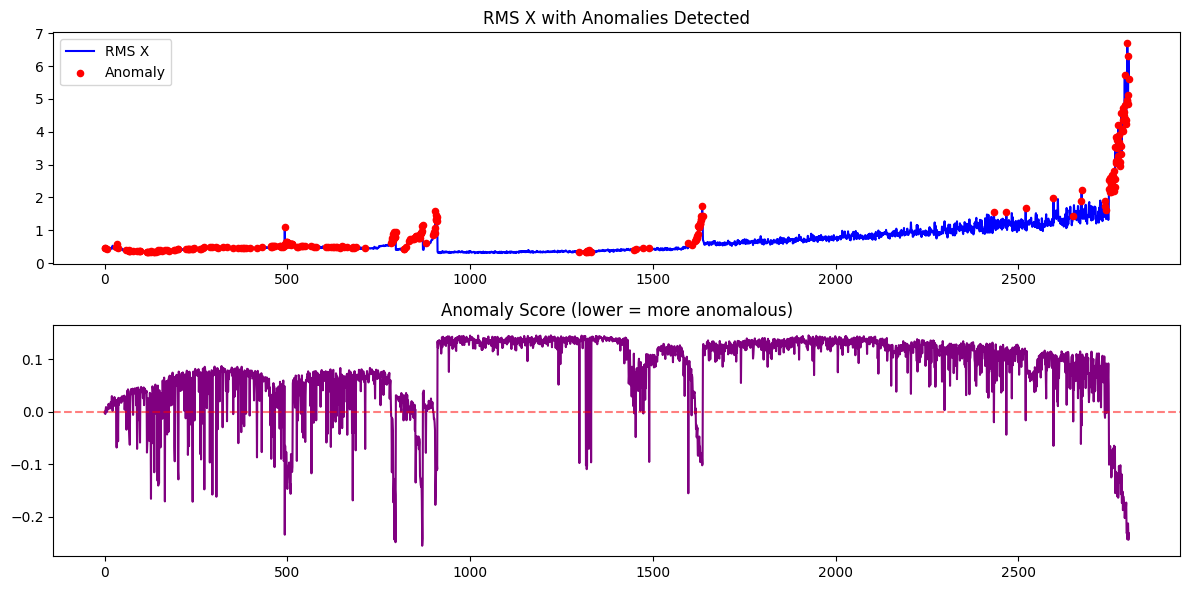

In [15]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 1, figsize=(12, 6))

# RMS with anomalies
axes[0].plot(features_df['snapshot_index'], features_df['rms_x'], color='blue', label='RMS X')
anomalies = features_df[features_df['anomaly'] == -1]
axes[0].scatter(anomalies['snapshot_index'], anomalies['rms_x'],
                color='red', s=20, label='Anomaly', zorder=5)
axes[0].set_title('RMS X with Anomalies Detected')
axes[0].legend()

# Anomaly score
axes[1].plot(features_df['snapshot_index'], features_df['anomaly_score'], color='purple')
axes[1].axhline(y=0, color='red', linestyle='--', alpha=0.5)
axes[1].set_title('Anomaly Score (lower = more anomalous)')

plt.tight_layout()
plt.savefig('anomaly_detection.png', dpi=150)
plt.show()